In [1]:
import pandas as pd

df = pd.read_csv('car data.csv')
df.head()
df.tail()
df.shape

(301, 9)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [3]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(2)

In [5]:
df.shape

(301, 9)

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("New shape: ",df.shape)


New shape:  (299, 9)


Having the Age column like how old the car is better than having the year, which will be helpful in comparing price with age of the car.

In [7]:
df['Age'] = 2026 - df['Year']
df.drop('Year',axis=1,inplace=True)

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

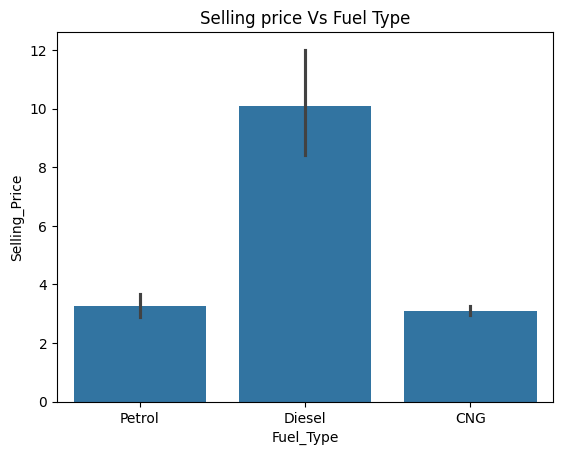

In [9]:
sns.barplot(x='Fuel_Type',y='Selling_Price',data=df)
plt.title("Selling price Vs Fuel Type")
plt.show()

From the analysis of selling price across fuel types, diesel vehicles tend to have higher selling prices compared to petrol and CNG vehicles. This may be due to diesel cars often belonging to larger vehicle categories such as SUVs and premium sedans, as well as their higher fuel efficiency and durability for long-distance driving.

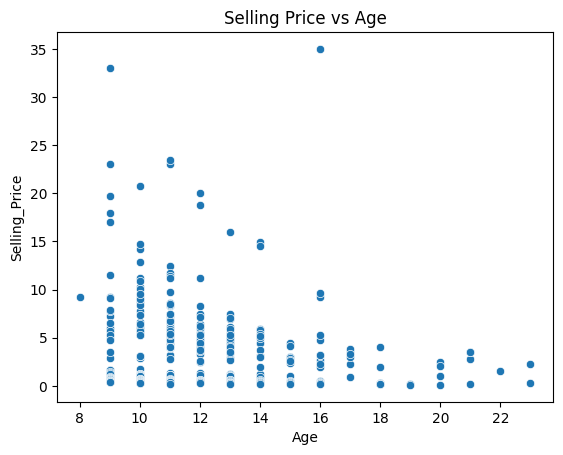

In [10]:
sns.scatterplot(x='Age',y="Selling_Price",data=df)
plt.title("Selling Price vs Age")
plt.show()

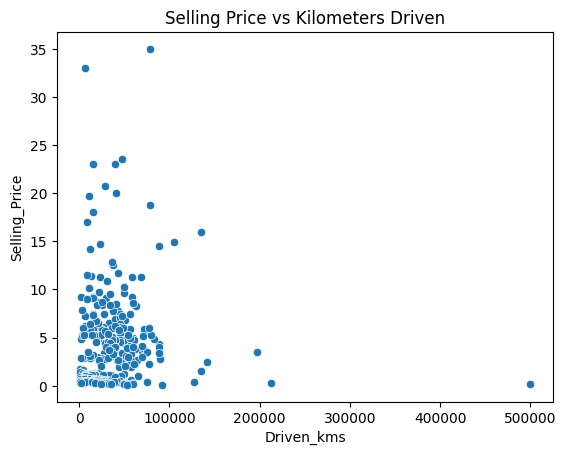

In [11]:

sns.scatterplot(x='Driven_kms', y='Selling_Price', data=df)
plt.title("Selling Price vs Kilometers Driven")
plt.show()

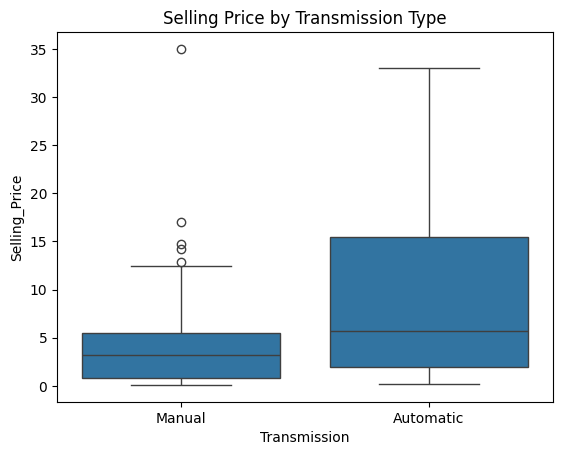

In [12]:
sns.boxplot(x='Transmission', y='Selling_Price', data=df)
plt.title("Selling Price by Transmission Type")
plt.show()

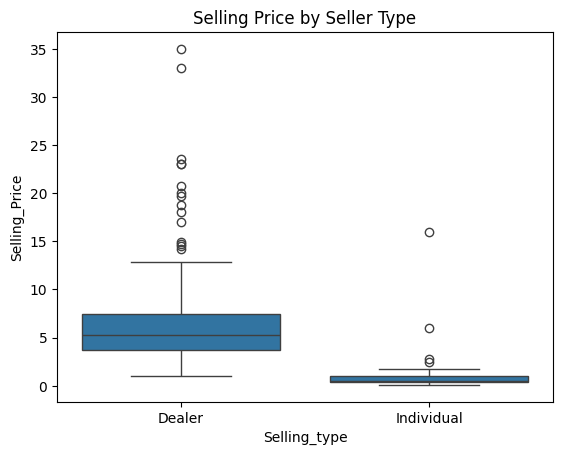

In [13]:
sns.boxplot(x='Selling_type', y='Selling_Price', data=df)
plt.title("Selling Price by Seller Type")
plt.show()

In [14]:
df.drop('Car_Name', axis=1, inplace=True)

Now,converting categorical columns into numerical columns using One Hot encoding.

In [15]:
df.shape

(299, 8)

In [16]:
df = pd.get_dummies(df,drop_first=True)

In [17]:
df.shape

(299, 9)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Selling_Price            299 non-null    float64
 1   Present_Price            299 non-null    float64
 2   Driven_kms               299 non-null    int64  
 3   Owner                    299 non-null    int64  
 4   Age                      299 non-null    int64  
 5   Fuel_Type_Diesel         299 non-null    bool   
 6   Fuel_Type_Petrol         299 non-null    bool   
 7   Selling_type_Individual  299 non-null    bool   
 8   Transmission_Manual      299 non-null    bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 13.0 KB


Now, starting model training phase.

X = all the inputs and features that will help predict Y which is the selling price.
Y = output, what we want( the selling price from all the input features.)

In [19]:
X = df.drop('Selling_Price',axis=1)
Y = df['Selling_Price']

After, this we divide the dataset into train and test sets beacuse, if we train the model on the same dataset it might start memorizing instead of learning the patter and would lead to overfitting, I will be using the standard 80-20 train/split.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

In [21]:
print(X_train.shape)
print(X_test.shape)

(239, 8)
(60, 8)


Now, that I have the train and split set i can start the model training, I will first train the Linear regression as the baseline model due its simplicity and interpetability.

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,Y_train)
y_pred = model.predict(X_test)


In [23]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print("MAE: ",mean_absolute_error(Y_test,y_pred))
print("RMSE: ",root_mean_squared_error(Y_test, y_pred))
print("R2 Score: ",r2_score(Y_test,y_pred))


MAE:  1.472545750817864
RMSE:  2.524504923001876
R2 Score:  0.7527233824220485


In [24]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coefficients)

                         Coefficient
Present_Price               0.437119
Driven_kms                 -0.000011
Owner                       0.640144
Age                        -0.330031
Fuel_Type_Diesel            2.142391
Fuel_Type_Petrol            0.692516
Selling_type_Individual    -1.302291
Transmission_Manual        -1.573425


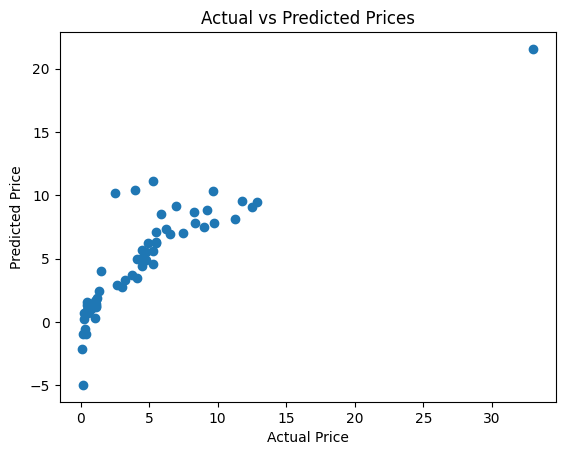

In [25]:
plt.scatter(Y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

## Linear Regression

A Linear Regression model was trained to predict the selling price of cars using features such as present price, kilometers driven, ownership history, fuel type, transmission type, and vehicle age.

The dataset was split into training and testing sets using an 80–20 split to evaluate model performance on unseen data.

The model achieved the following performance metrics:

- MAE  = 1.47
- RMSE = 2.52
- R²   = 0.75

The R² score of 0.75 indicates that the model explains approximately 75% of the variance in car selling prices, suggesting a reasonably good fit.

Feature coefficient analysis revealed that:

- Present Price has the strongest positive impact on resale value.

- Vehicle Age negatively affects the selling price due to depreciation.

- Diesel vehicles tend to have higher resale values.

- Manual transmission cars generally sell for lower prices compared to automatic cars.

- Cars sold by individual sellers tend to have lower prices compared to dealer-listed vehicles.

The scatter plot of actual versus predicted prices shows a generally increasing trend, confirming that the model captures the relationship between features and car price. However, deviations from the diagonal line indicate that linear regression struggles to capture complex, non-linear relationships in the data.

Therefore, a more powerful model such as Random Forest Regressor will be explored next to improve prediction accuracy.

In [26]:
from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

RF.fit(X_train,Y_train)
y_pred_rf = RF.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print("MAE: ",mean_absolute_error(Y_test,y_pred_rf))
print("RMSE: ",root_mean_squared_error(Y_test,y_pred_rf))
print("R2 score: ",r2_score(Y_test,y_pred_rf))

MAE:  1.3542990155918162
RMSE:  3.1529724385573825
R2 score:  0.6142810672321117


In [28]:
df.corr()["Selling_Price"].sort_values()

Selling_type_Individual   -0.553851
Fuel_Type_Petrol          -0.531636
Transmission_Manual       -0.348869
Age                       -0.234369
Owner                     -0.087880
Driven_kms                 0.028566
Fuel_Type_Diesel           0.543541
Present_Price              0.876305
Selling_Price              1.000000
Name: Selling_Price, dtype: float64

## Random Forest Regressor

To capture potential non-linear relationships in the dataset, a Random Forest Regressor was trained. Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and reduce variance.

The model was trained using the same training dataset used for the Linear Regression model. Several hyperparameters such as the number of trees and tree depth were adjusted to improve generalization and reduce overfitting.

The Random Forest model achieved the following performance:

- MAE  = 1.35
- RMSE = 3.15
- R²   = 0.61

Although the Mean Absolute Error slightly improved compared to Linear Regression, the RMSE increased and the R² score decreased, indicating that the model struggled to capture the overall variance of car prices in the dataset.

This suggests that while Random Forest handled some individual predictions well, it produced larger errors for certain cases, particularly for higher priced vehicles.